# 3. Feature Availability Analysis -- Logistic Regression

Can final academic outcome be predicted using information available at different stages of a student's progression?

Three predictor sets:
- **Day 1:** before any semester performance exists
- **After Semester 1:** semester 1 performance known
- **Full Data:** both semesters known

In [ ]:
import sys
from pathlib import Path


cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluate import evaluate_feature_set
from src.models import get_logistic_regression
from src.preprocessing import get_feature_availability_sets, load_data

sns.set_theme(style="whitegrid")
df = load_data()


## 3.1 Define feature sets

In [2]:
feature_sets = get_feature_availability_sets(df)

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} predictors")


Day 1: 22 predictors
After Semester 1: 28 predictors
Full Data: 34 predictors


## 3.2 Logistic Regression across feature sets

In [3]:
feature_results = [
    evaluate_feature_set(df, cols, name, get_logistic_regression(), scale_numeric=True)
    for name, cols in feature_sets.items()
]

feature_results_df = pd.DataFrame(feature_results)
display(feature_results_df.round(3))

# Save so 05_model_comparison.ipynb can load it without recomputing
feature_results_df.to_csv("../data/processed/logreg_feature_availability.csv", index=False)


,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Day 1,0.567,0.541,0.585,0.484,0.586
1,After Semester 1,0.692,0.652,0.673,0.560,0.751
2,Full Data,0.723,0.685,0.690,0.616,0.783


## 3.3 Visualize results
### 3.3.1 Macro F1 and accuracy

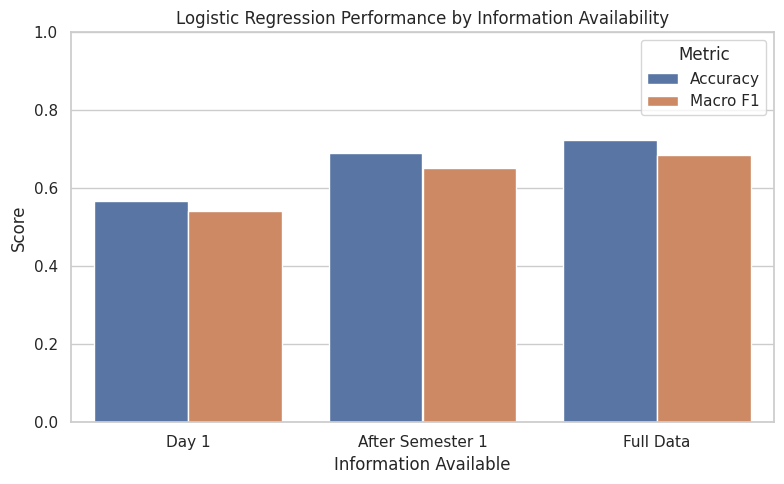

In [4]:
feature_performance_long = feature_results_df.melt(
    id_vars="Feature Set", value_vars=["Accuracy", "Macro F1"],
    var_name="Metric", value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feature_performance_long, x="Feature Set", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Logistic Regression Performance by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()


### 3.3.2 Recall for each outcome

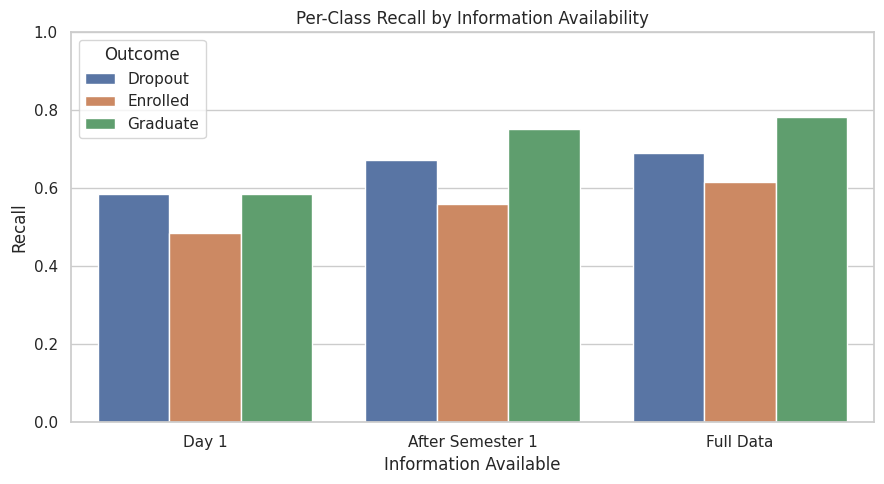

In [5]:
feature_recall_long = feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Dropout Recall", "Enrolled Recall", "Graduate Recall"],
    var_name="Outcome", value_name="Recall"
)
feature_recall_long["Outcome"] = feature_recall_long["Outcome"].str.replace(" Recall", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=feature_recall_long, x="Feature Set", y="Recall", hue="Outcome", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Per-Class Recall by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Recall")
plt.tight_layout()
plt.show()
